## Research question: Which listing strategies maximize the probability of selling above asking price?

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    r"C:\Users\irisz\OneDrive\桌面\IDX Exchange\listings_with_rates_clean_filtered.csv")

print(df.shape)
df.head()

(118480, 99)


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,close_to_original_list_ratio,price_per_sqft,close_year,close_month,close_yrmo,listing_to_contract_days,contract_to_close_days,ClosePrice_outlier_flag,LivingArea_outlier_flag,DaysOnMarket_outlier_flag
0,1249888.0,1073295259,sandra.mcfetridge@gmail.com,2024-05-01,1262555.0,Sandra,McFetridge,33.477414,-117.664879,33450 Paseo El Lazo,...,1.010135,664.852554,2024,5,2024-05,20.0,73.0,False,False,False
1,650000.0,1073219502,lorijo@tcsn.net,2024-03-15,650000.0,Lori Jo,Stribling,35.508840,-120.690614,5405 San Benito Road,...,1.000000,464.285714,2024,3,2024-03,10.0,43.0,False,False,False
2,1025000.0,1073169832,doug@socalmodern.com,2024-05-02,962500.0,Douglas,Kramer,33.812886,-118.097004,3108 Kallin Avenue,...,0.939024,851.769912,2024,5,2024-05,104.0,2.0,False,False,False
3,725000.0,1073164974,zachmickelson1@gmail.com,2024-04-30,725000.0,Zachary,Mickelson,33.740706,-117.888816,505 S Spruce Street,...,1.000000,580.000000,2024,4,2024-04,18.0,81.0,False,False,False
4,730000.0,1071104851,Antonio@AntonioMatier.com,2024-04-09,730000.0,Antonio,Matier,NaN,NaN,2456 Havenscourt Blvd,...,1.000000,576.619273,2024,4,2024-04,35.0,58.0,False,False,False


In [2]:
print(df.columns)

Index(['OriginalListPrice', 'ListingKey', 'ListAgentEmail', 'CloseDate',
       'ClosePrice', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude',
       'Longitude', 'UnparsedAddress', 'PropertyType', 'LivingArea',
       'ListPrice', 'DaysOnMarket', 'ListOfficeName', 'BuyerOfficeName',
       'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName',
       'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName',
       'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency',
       'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor',
       'TaxAnnualAmount', 'CountyOrParish', 'MlsStatus', 'ElementarySchool',
       'AttachedGarageYN', 'ParkingTotal', 'BuilderName', 'PropertySubType',
       'LotSizeAcres', 'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt',
       'BuyerAgencyCompensationType', 'StreetNumberNumeric', 'ListingId',
       'BathroomsTotalInteger', 'City', 'BuyerAgencyCompensation', 'TaxYear',
       'BuildingAreaTotal', 'BedroomsTota

In [3]:
required_columns = [
    "ListingKey",
    "CloseDate",
    "ClosePrice",
    "OriginalListPrice",
    "ListPrice",
    "LivingArea",
    "DaysOnMarket",
    "ListOfficeName",
    "ListAgentFullName",
    "City",
    "CountyOrParish",
    "PropertySubType",
    "rate_30yr_fixed"
]

missing_columns = [
    column for column in required_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

data = df[required_columns].copy()

numeric_columns = [
    "ClosePrice",
    "OriginalListPrice",
    "ListPrice",
    "LivingArea",
    "DaysOnMarket",
    "rate_30yr_fixed"
]

for column in numeric_columns:
    data[column] = pd.to_numeric(data[column], errors="coerce")

data["CloseDate"] = pd.to_datetime(
    data["CloseDate"],
    errors="coerce"
)

# Remove duplicate transactions if ListingKey should uniquely identify a listing
data = data.drop_duplicates(subset="ListingKey")

Then use basic validity filters

In [4]:
data = data[
    (data["ClosePrice"] > 0)
    & (data["OriginalListPrice"] > 0)
    & (data["LivingArea"] > 0)
    & (data["DaysOnMarket"] >= 0)
    & data["CloseDate"].notna()
].copy()

# Remove implausible sale-to-original-list ratios
data["close_to_original_ratio"] = (
    data["ClosePrice"] / data["OriginalListPrice"]
)

data = data[
    data["close_to_original_ratio"].between(0.50, 1.50)
].copy()

# Classification outcome
data["sold_above_original_asking"] = (
    data["ClosePrice"] > data["OriginalListPrice"]
).astype(int)

print(f"Usable observations: {len(data):,}")
print(
    "Percent sold above original asking:",
    f"{data['sold_above_original_asking'].mean():.2%}"
)

Usable observations: 117,407
Percent sold above original asking: 46.40%


Using OriginalListPrice is appropriate because it measures whether the final price exceeded the property’s initial asking price, rather than a later reduced list price.

After that alculate original list price per square foot:

In [5]:
data["original_list_price_per_sqft"] = (
    data["OriginalListPrice"] / data["LivingArea"]
)

data["close_year_month"] = (
    data["CloseDate"]
    .dt.to_period("M")
    .astype(str)
)

Then define comparable groups:

In [6]:
comparable_group = [
    "City",
    "PropertySubType",
    "close_year_month"
]

group_statistics = (
    data.groupby(comparable_group)
    ["original_list_price_per_sqft"]
    .agg(
        comparable_count="count",
        comparable_median_list_ppsf="median"
    )
    .reset_index()
)

data = data.merge(
    group_statistics,
    on=comparable_group,
    how="left"
)

Create the relative pricing variable:

In [7]:
data["relative_listing_price"] = (
    data["original_list_price_per_sqft"]
    / data["comparable_median_list_ppsf"]
)

data["pricing_discount_pct"] = (
    1 - data["relative_listing_price"]
) * 100

It means that
* relative_listing_price = 0.95: listed approximately 5% below its peer-group median.
* relative_listing_price = 1.00: listed near the peer-group median.
* relative_listing_price = 1.10: listed approximately 10% above the peer-group median.

In [8]:
data = data[
    data["comparable_count"] >= 20
].copy()

This is still a proxy for market value, not a formal appraisal. It controls for city, property type, month, and size through price per square foot.

Create pricing-strategy categories

In [9]:
pricing_conditions = [
    data["relative_listing_price"] < 0.90,
    data["relative_listing_price"].between(
        0.90, 0.95, inclusive="left"
    ),
    data["relative_listing_price"].between(
        0.95, 0.98, inclusive="left"
    ),
    data["relative_listing_price"].between(
        0.98, 1.02, inclusive="both"
    ),
    data["relative_listing_price"].between(
        1.02, 1.05, inclusive="right"
    ),
    data["relative_listing_price"] > 1.05
]

pricing_labels = [
    "More than 10% below peers",
    "5%–10% below peers",
    "2%–5% below peers",
    "Within 2% of peers",
    "2%–5% above peers",
    "More than 5% above peers"
]

data["pricing_strategy"] = np.select(
    pricing_conditions,
    pricing_labels,
    default=np.nan
)

pricing_order = pricing_labels

Summarize the findings:

In [10]:
pricing_summary = (
    data.dropna(subset=["pricing_strategy"])
    .groupby("pricing_strategy", observed=True)
    .agg(
        observations=("ListingKey", "size"),
        probability_above_asking=(
            "sold_above_original_asking",
            "mean"
        ),
        average_close_to_original_ratio=(
            "close_to_original_ratio",
            "mean"
        ),
        median_close_to_original_ratio=(
            "close_to_original_ratio",
            "median"
        ),
        median_days_on_market=(
            "DaysOnMarket",
            "median"
        )
    )
    .reindex(pricing_order)
    .reset_index()
)

pricing_summary["probability_above_asking"] *= 100
pricing_summary["average_close_to_original_ratio"] *= 100
pricing_summary["median_close_to_original_ratio"] *= 100

print(pricing_summary.round(2))

            pricing_strategy  observations  probability_above_asking  \
0  More than 10% below peers         16496                     49.56   
1         5%–10% below peers          5169                     45.70   
2          2%–5% below peers          3269                     46.62   
3         Within 2% of peers          5468                     46.14   
4          2%–5% above peers          3081                     48.30   
5   More than 5% above peers         21966                     45.72   

   average_close_to_original_ratio  median_close_to_original_ratio  \
0                           101.49                           100.0   
1                           100.81                           100.0   
2                           100.97                           100.0   
3                           100.69                           100.0   
4                           100.87                           100.0   
5                           100.62                           100.0   

   m

I find out Homes listed more than 10% below their peer-group median had:

* The highest above-asking probability: 49.56%
* The highest average sale-to-original-list ratio: 101.49%
* The shortest median Days on Market: 11 days
By comparison, homes listed more than 5% above peers had a 45.72% probability of selling above asking and an average ratio of 100.62%. The difference in above-asking probability between these groups is about 3.84 percentage points. Homes priced:

* 2%–5% below peers: 46.62%
* 5%–10% below peers: 45.70%
* Within 2% of peers: 46.14%
None of these moderately underpriced groups outperformed homes listed more than 10% below peers. Surprisingly, the 2%–5% above-peer group had the second-highest above-asking probability at 48.30%. Therefore, the relationship is not simply: The lower the initial price, the greater the chance of selling above asking.Instead, the pattern appears nonlinear.

From the data we had, we can analyzed that the descriptive results provide partial evidence that aggressive underpricing is associated with stronger bidding outcomes. Homes listed more than 10% below the median list price per square foot of comparable properties had the highest probability of selling above their original asking price, at 49.56%, compared with 45.72% for homes listed more than 5% above comparable properties. Aggressively underpriced homes also had the highest average close-to-original-list ratio, at 101.49%, and sold approximately one day faster based on median Days on Market.

However, the results do not support the hypothesis that homes listed only slightly below market value consistently perform best. Listings priced 2%–5% below comparable properties had an above-asking probability of 46.62%, which was lower than both the aggressively underpriced group and the group priced 2%–5% above comparable properties. In addition, the median close-to-original-list ratio was 100% across every pricing category, indicating that the typical home sold at its original asking price.

Overall, aggressive underpricing appears to increase the likelihood of generating above-asking offers, but the improvement is modest and may partly reflect the lower asking-price benchmark. Further analysis of final sale price relative to comparable sales is needed before concluding that underpricing maximizes the seller’s total proceeds.

Strategic underpricing will mechanically make the sale-to-list ratio easier to exceed. Therefore, a high ClosePrice / OriginalListPrice does not automatically mean the seller received more money.

Create final sale price per square foot relative to comparable properties:

In [11]:
data["close_price_per_sqft"] = (
    data["ClosePrice"] / data["LivingArea"]
)

close_group_stats = (
    data.groupby(comparable_group)
    ["close_price_per_sqft"]
    .median()
    .rename("comparable_median_close_ppsf")
    .reset_index()
)

data = data.merge(
    close_group_stats,
    on=comparable_group,
    how="left"
)

data["relative_final_sale_price"] = (
    data["close_price_per_sqft"]
    / data["comparable_median_close_ppsf"]
)

Then compare both outcomes:

In [12]:
pricing_value_summary = (
    data.dropna(subset=["pricing_strategy"])
    .groupby("pricing_strategy", observed=True)
    .agg(
        observations=("ListingKey", "size"),
        probability_above_asking=(
            "sold_above_original_asking",
            "mean"
        ),
        average_sale_to_original_ratio=(
            "close_to_original_ratio",
            "mean"
        ),
        average_relative_final_sale_price=(
            "relative_final_sale_price",
            "mean"
        ),
        median_dom=("DaysOnMarket", "median")
    )
    .reindex(pricing_order)
)

print(pricing_value_summary.round(4))

                           observations  probability_above_asking  \
pricing_strategy                                                    
More than 10% below peers         16496                    0.4956   
5%–10% below peers                 5169                    0.4570   
2%–5% below peers                  3269                    0.4662   
Within 2% of peers                 5468                    0.4614   
2%–5% above peers                  3081                    0.4830   
More than 5% above peers          21966                    0.4572   

                           average_sale_to_original_ratio  \
pricing_strategy                                            
More than 10% below peers                          1.0149   
5%–10% below peers                                 1.0081   
2%–5% below peers                                  1.0097   
Within 2% of peers                                 1.0069   
2%–5% above peers                                  1.0087   
More than 5% above p

In [13]:
pricing_value_summary = (
    data.dropna(subset=["pricing_strategy"])
    .groupby("pricing_strategy", observed=True)
    .agg(
        observations=("ListingKey", "size"),
        probability_above_asking=(
            "sold_above_original_asking",
            "mean"
        ),
        average_sale_to_original_ratio=(
            "close_to_original_ratio",
            "mean"
        ),
        average_relative_final_sale_price=(
            "relative_final_sale_price",
            "mean"
        ),
        median_dom=("DaysOnMarket", "median")
    )
    .reindex(pricing_order)
    .reset_index()
)

percentage_columns = [
    "probability_above_asking",
    "average_sale_to_original_ratio",
    "average_relative_final_sale_price"
]

pricing_value_summary[percentage_columns] = (
    pricing_value_summary[percentage_columns] * 100
)

print(pricing_value_summary.round(2))

            pricing_strategy  observations  probability_above_asking  \
0  More than 10% below peers         16496                     49.56   
1         5%–10% below peers          5169                     45.70   
2          2%–5% below peers          3269                     46.62   
3         Within 2% of peers          5468                     46.14   
4          2%–5% above peers          3081                     48.30   
5   More than 5% above peers         21966                     45.72   

   average_sale_to_original_ratio  average_relative_final_sale_price  \
0                          101.49                              78.71   
1                          100.81                              92.64   
2                          100.97                              96.50   
3                          100.69                             100.00   
4                          100.87                             103.76   
5                          100.62                             1

probability_above_asking = 49.56 means 49.56% of homes sold above their original asking price.
* average_sale_to_original_ratio = 101.49 means homes sold for an average of 101.49% of original asking price.
* average_relative_final_sale_price = 98.50 means the homes’ final sale price per square foot averaged 98.50% of the peer-group median sale price per square foot.
* average_relative_final_sale_price = 102.00 means they sold for approximately 2% more than comparable homes.

 Homes listed more than 10% below peers have a high above-asking probability but an average relative final sale price below 100%, the strategy generates bidding activity but does not maximize seller proceeds. If homes listed 2%–5% below peers have a relative final sale price above 100%, modest underpricing may be the better strategy.If homes priced near or above peers achieve the highest relative final sale price, underpricing may increase the sale-to-list ratio without increasing the amount sellers ultimately receive.

Plot the pricing-strategy result:

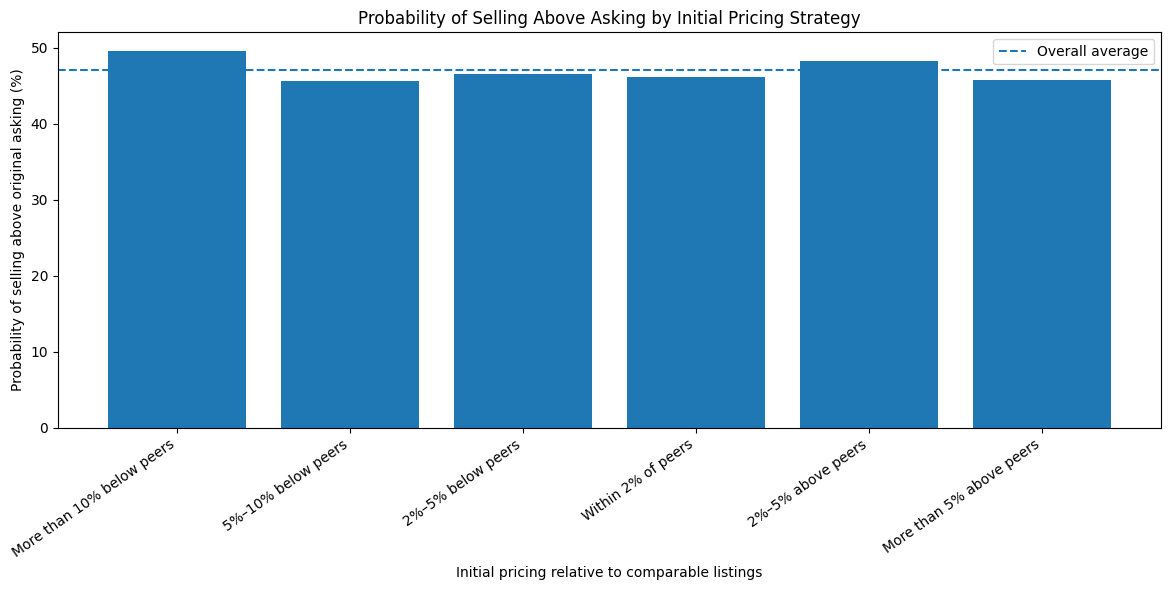

In [14]:
import matplotlib.pyplot as plt

plot_data = pricing_summary.dropna(
    subset=["probability_above_asking"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_data["pricing_strategy"],
    plot_data["probability_above_asking"]
)

plt.axhline(
    data["sold_above_original_asking"].mean() * 100,
    linestyle="--",
    label="Overall average"
)

plt.xlabel("Initial pricing relative to comparable listings")
plt.ylabel("Probability of selling above original asking (%)")
plt.title(
    "Probability of Selling Above Asking by Initial Pricing Strategy"
)
plt.xticks(rotation=35, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

This chart is actually quite interesting because the differences are much smaller than many real estate practitioners might expect. The visual suggests that pricing strategy alone is not the dominant driver of selling above asking. Initial pricing strategy influences the likelihood of selling above asking, but its impact appears relatively modest.

Homes listed more than 10% below comparable listings achieved 49.56% probability of selling above asking Highest average sale-to-list ratio Fastest median sale time This supports the idea that aggressive underpricing can stimulate buyer competition. It conclude that homes listed slightly below market value does not actually sell for more.There is no evidence that pricing only slightly below market consistently increases the chance of selling above asking. That is actually a valuable research finding because it contradicts a common belief we have.One surprising result is 2–5% above peers has48.3%which is almost as high as the aggressively underpriced group.Possible explanations include:
* neighborhoods
* luxury homes
* sellers who intentionally priced high because demand was strong experienced listing agents desirable property characteristics

This suggests that pricing strategy is interacting with property quality and market conditions.

# Statitcal model 

In [15]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    data["pricing_strategy"],
    data["sold_above_original_asking"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square:", chi2)
print("p-value:", p)

Chi-square: 65.24650104187708
p-value: 9.9625000119551e-13


Since p valus is <0.05 it is statistically significant.Pricing strategy and selling above asking are statistically associate but there are other factors need to be considered. 

Therefore, for a seller, the practical implication are nuanced.Aggressively underpricing may increase bidding competition and the chance of selling above asking. However, the improvement is relatively small (about 4 percentage points).Pricing slightly below market does not outperform pricing near or slightly above comparable listings.
Therefore, pricing strategy alone is unlikely to maximize seller outcomes; market conditions, property characteristics, and listing quality are likely more influential.

Agents and offices can have many unique values. Keep only those with sufficient transactions and group the rest as "Other".

In [16]:
def combine_rare_categories(
    series,
    minimum_count=30,
    replacement="Other"
):
    counts = series.value_counts(dropna=False)
    common = counts[counts >= minimum_count].index

    return series.where(
        series.isin(common),
        replacement
    )


for column in [
    "ListAgentFullName",
    "ListOfficeName",
    "City"
]:
    data[column] = data[column].fillna("Unknown")

data["AgentModel"] = combine_rare_categories(
    data["ListAgentFullName"],
    minimum_count=30
)

data["OfficeModel"] = combine_rare_categories(
    data["ListOfficeName"],
    minimum_count=50
)

data["CityModel"] = combine_rare_categories(
    data["City"],
    minimum_count=50
)

data["PropertySubType"] = (
    data["PropertySubType"].fillna("Unknown")
)

# Logistical regression model

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix
)

Choose predictor

In [28]:
columns_to_add = [
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger"
]

for column in columns_to_add:
    if column not in data.columns:
        data[column] = df.loc[data.index, column]

In [29]:
numeric_features = [
    "relative_listing_price",
    "DaysOnMarket",
    "rate_30yr_fixed",
    "LivingArea",
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger"
]

categorical_features = [
    "OfficeModel",
    "AgentModel",
    "CityModel",
    "PropertySubType"
]

model_columns = (
    numeric_features
    + categorical_features
    + ["sold_above_original_asking", "CloseDate"]
)

model_data = data[model_columns].copy()

for column in numeric_features:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce"
    )

Check missing column

In [30]:
numeric_features = [
    "relative_listing_price",
    "DaysOnMarket",
    "rate_30yr_fixed",
    "LivingArea",
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger"
]

categorical_features = [
    "OfficeModel",
    "AgentModel",
    "CityModel",
    "PropertySubType"
]

model_columns = (
    numeric_features
    + categorical_features
    + ["sold_above_original_asking", "CloseDate"]
)

missing_model_columns = [
    column for column in model_columns
    if column not in data.columns
]

print("Missing model columns:", missing_model_columns)

Missing model columns: []


In [31]:
model_data = data[model_columns].copy()

for column in numeric_features:
    model_data[column] = pd.to_numeric(
        model_data[column],
        errors="coerce"
    )

model_data["CloseDate"] = pd.to_datetime(
    model_data["CloseDate"],
    errors="coerce"
)

print(model_data.shape)
print(model_data.isna().sum())

(55449, 13)
relative_listing_price        0
DaysOnMarket                  0
rate_30yr_fixed               0
LivingArea                    0
YearBuilt                     0
BedroomsTotal                 0
BathroomsTotalInteger         0
OfficeModel                   0
AgentModel                    0
CityModel                     0
PropertySubType               0
sold_above_original_asking    0
CloseDate                     0
dtype: int64


After that Use a chronological split rather than a random split. This gives a more realistic test of whether the model generalizes to later transactions.

In [32]:
model_data = model_data.sort_values("CloseDate")

split_position = int(len(model_data) * 0.80)

train_data = model_data.iloc[:split_position].copy()
test_data = model_data.iloc[split_position:].copy()

X_train = train_data[
    numeric_features + categorical_features
]

y_train = train_data["sold_above_original_asking"]

X_test = test_data[
    numeric_features + categorical_features
]

y_test = test_data["sold_above_original_asking"]

In [33]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_transformer,
            numeric_features
        ),
        (
            "categorical",
            categorical_transformer,
            categorical_features
        )
    ]
)

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="liblinear"
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['relative_listing_price',
                                                   'DaysOnMarket',
                                                   'rate_30yr_fixed',
                                                   'LivingArea', 'YearBuilt',
                                                   'BedroomsTotal',
                                                   'BathroomsTotalInteger']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['OfficeModel', 'AgentModel',
                                                   'CityModel',
                                                   'PropertySubType'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=3000,
                                    solver='liblinear'))])

In [34]:
predicted_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

predicted_class = (
    predicted_probability >= 0.50
).astype(int)

print(
    classification_report(
        y_test,
        predicted_class
    )
)

print(
    "Test ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            predicted_probability
        ),
        4
    )
)

print(
    "Confusion matrix:\n",
    confusion_matrix(
        y_test,
        predicted_class
    )
)

              precision    recall  f1-score   support

           0       0.70      0.80      0.75      6671
           1       0.62      0.49      0.55      4419

    accuracy                           0.68     11090
   macro avg       0.66      0.65      0.65     11090
weighted avg       0.67      0.68      0.67     11090

Test ROC-AUC: 0.7399
Confusion matrix:
 [[5343 1328]
 [2249 2170]]


From the result, I Find out the accuracy is	68%	Correctly classifies about 2 out of 3 homes.ROC-AUC	0.7399	Good discrimination; the model ranks above-asking homes ahead of below-asking homes about 74% of the time.
Precision 0.62 When the model predicts a home will sell above asking, it is correct 62% of the time. Recall (Above Asking)is 0.49.The model identifies about half of all homes that actually sell above asking. The confusion matrix indicates that True Negatives 5343 Homes correctly predicted not to sell above asking.True Positives 2170 Homes correctly predicted to sell above asking.False Positives 1328 means the model predicted above asking, but the home did not.False Negatives 2249 Homes that actually sold above asking but the model missed.

In conclusion, Selling above asking is predictable, but not deterministic. There are many influences beyond pricing strategy, including:
* neighborhood desirability
* school district
* market competition
* listing quality
* buyer demand
* seasonality
* mortgage rates



Categorical classicication

In [35]:
feature_names = (
    logistic_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

coefficients = (
    logistic_model
    .named_steps["classifier"]
    .coef_[0]
)

odds_ratio_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "OddsRatio": np.exp(coefficients)
})

odds_ratio_table["AbsoluteCoefficient"] = (
    odds_ratio_table["Coefficient"].abs()
)

odds_ratio_table = odds_ratio_table.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

print(
    odds_ratio_table[
        [
            "Feature",
            "Coefficient",
            "OddsRatio"
        ]
    ].head(30)
)

                                               Feature  Coefficient  OddsRatio
176              categorical__AgentModel_NYLA STERLING     2.327101  10.248184
157                categorical__AgentModel_Cesi Pagano    -2.268407   0.103477
197                    categorical__CityModel_Berkeley     2.038638   7.680142
189                     categorical__CityModel_Alameda     1.660689   5.262938
269                categorical__CityModel_Palm Springs    -1.424890   0.240535
299                 categorical__CityModel_Santa Clara     1.423611   4.152085
137         categorical__OfficeModel_The GRUBB Company     1.419243   4.133990
177             categorical__AgentModel_Omar Elminoufi     1.381898   3.982453
261                     categorical__CityModel_Oakland     1.239150   3.452677
185                categorical__AgentModel_Renee White    -1.221340   0.294835
126            categorical__OfficeModel_Red Oak Realty     1.195411   3.304915
206              categorical__CityModel_Cathedral Ci

Interpretation of odds ratio:

* OddsRatio > 1: associated with higher odds of selling above asking.
* OddsRatio < 1: associated with lower odds.
For standardized numeric variables, the odds ratio represents approximately a one-standard-deviation increase.Agent and office effects are relative to the one-hot encoder’s reference structure and should not automatically be interpreted causally.

These coefficients are interesting, but be careful not to over-interpret the agent, office, and city effects. The logistic regression coefficients are conditional associations, not causal effects. They tell us which features are associated with a higher or lower probability of selling above asking after controlling for the other variables in the model.The strongest numeric predictor is:coefficient -0.947. It means that Homes that remain on the market longer are significantly less likely to sell above asking. Odds Ratio is 0.388. An odds ratio of 0.388 means that a one-standard-deviation increase in Days on Market (because you standardized numeric variables) reduces the odds of selling above asking by about 61%:


After accounting for the variables in the model, listings in these cities had higher odds of selling above asking than the model's reference city.Possible reasons include:

* stronger demand
* tighter inventory
* desirable school districts
* higher-income buyers

These should not be interpreted as "living in Berkeley causes a home to sell above asking."

Another finding is Longer Days on Market substantially reduces the likelihood of selling above asking.Several cities exhibit substantially higher adjusted probabilities of above-asking sales. Pricing strategy has some influence but appears less important than market conditions.

## Use Random Forest method


In [36]:
X = model_data.drop(
    columns=["sold_above_original_asking", "CloseDate"]
)

y = model_data["sold_above_original_asking"]

Train and test data

In [37]:
split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [38]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = [
    "relative_listing_price",
    "DaysOnMarket",
    "rate_30yr_fixed",
    "LivingArea",
    "YearBuilt",
    "BedroomsTotal",
    "BathroomsTotalInteger"
]

categorical_features = [
    "OfficeModel",
    "AgentModel",
    "CityModel",
    "PropertySubType"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [40]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['relative_listing_price',
                                                   'DaysOnMarket',
                                                   'rate_30yr_fixed',
                                                   'LivingArea', 'YearBuilt',
                                                   'BedroomsTotal',
                                                   'BathroomsTotalInteger']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['OfficeModel', 'AgentModel',
                                                   'CityModel',
                                                   'PropertySubType'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_leaf=5, n_estimators=500,
                                        n_jobs=-1, random_state=42))])

Evaluate Random Forest model

In [41]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix
)

pred = rf_model.predict(X_test)

prob = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test, pred))

print("Accuracy:", accuracy_score(y_test, pred))

print("ROC AUC:", roc_auc_score(y_test, prob))

print(confusion_matrix(y_test, pred))

              precision    recall  f1-score   support

           0       0.75      0.78      0.77      6671
           1       0.65      0.62      0.63      4419

    accuracy                           0.71     11090
   macro avg       0.70      0.70      0.70     11090
weighted avg       0.71      0.71      0.71     11090

Accuracy: 0.7146979260595131
ROC AUC: 0.772243934178697
[[5199 1472]
 [1692 2727]]


Compare to logitsic model, Random Forest's results are better than the logistic regression and indicate that the Random Forest captures additional nonlinear patterns in the data. For example, Logistic Regression found 49% of homes that sold above asking while Random Forest finds 62%.at's about a 26% relative improvement in identifying above-asking sales:(0.62−0.49​)/0.49=26.5%.This is important because missing above-asking homes (false negatives) is often more costly in this application than incorrectly predicting a few extra above-asking sales. Therefore, Random Forest provides stronger evidence because it captures nonlinear relationships and interactions among pricing strategy, location, and property characteristics.

In summary  Random Forest classifier was developed to predict whether a property would sell above its original asking price. The model achieved an overall accuracy of 71.5% and a ROC-AUC of 0.772, outperforming the logistic regression model (accuracy = 68.0%, ROC-AUC = 0.740). In particular, the Random Forest improved the recall for above-asking sales from 49% to 62%, demonstrating a substantially greater ability to identify listings that ultimately sold above asking. These results indicate that nonlinear relationships and interactions among pricing strategy, property characteristics, market conditions, and location contribute meaningfully to above-asking sale outcomes.

Feature imporatnce: 

In [42]:
feature_names = (
    rf_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = (
    rf_model.named_steps["classifier"]
    .feature_importances_
)

importance_df = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

importance_df.head(30)

,Feature,Importance
1,num__DaysOnMarket,0.486421
2,num__rate_30yr_fixed,0.088514
3,num__LivingArea,0.058435
0,num__relative_listing_price,0.050211
292,cat__CityModel_San Jose,0.028259
4,num__YearBuilt,0.026276
261,cat__CityModel_Oakland,0.021139
325,cat__PropertySubType_Condominium,0.016663
326,cat__PropertySubType_SingleFamilyResidence,0.013394
5,num__BedroomsTotal,0.009832


Aggregate one-hot encoded features



Instead of looking at hundreds of individual cities or agents, combine them into broader categories:

In [43]:
importance_df["FeatureGroup"] = (
    importance_df["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace(r"categorical__.*?_", "", regex=True)
)

group_importance = (
    importance_df
    .groupby("FeatureGroup")["Importance"]
    .sum()
    .sort_values(ascending=False)
)

print(group_importance)

FeatureGroup
num__DaysOnMarket                      0.486421
num__rate_30yr_fixed                   0.088514
num__LivingArea                        0.058435
num__relative_listing_price            0.050211
cat__CityModel_San Jose                0.028259
                                         ...   
cat__AgentModel_Lori Young             0.000017
cat__OfficeModel_Circle Real Estate    0.000016
cat__AgentModel_Patrick Mercer         0.000015
cat__AgentModel_Jonathan Minerick      0.000014
cat__AgentModel_Benjamin Hitchins      0.000008
Name: Importance, Length: 329, dtype: float64


Visualize the top features 

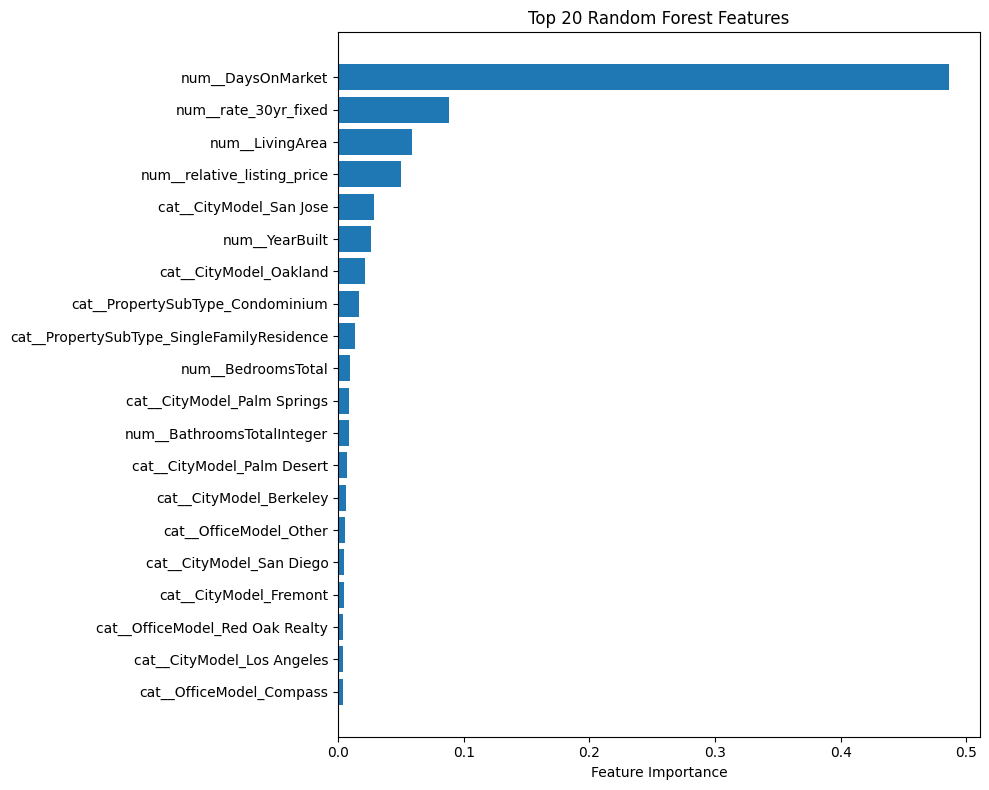

In [44]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20["Feature"][::-1],
    top20["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.title("Top 20 Random Forest Features")

plt.tight_layout()
plt.show()

The Random Forest model shows that not all listing factors are equally important. A small number of variables explain most of the predictive power, with Days on Market dominating all other features.Homes that sell quickly are much more likely to sell above asking price.This finding is consistent with real estate market theory: Highly desirable homes attract offers soon after listing. Multiple offers typically occur within the first one to two weeks. Listings that remain on the market longer often experience weaker demand and price reductions.The second most important variable is rate_30yr_fixed.Lower mortgage rates generally

* increase buyer purchasing power,
* attract more buyers,
* increase competition,
* increase the likelihood of bidding wars.

This suggests that listing timing, not just pricing strategy, affects selling outcomes.
The third most important predictor is LivingAreaThis indicates that larger homes behave differently in the market than smaller homes.

* buyer segments
* inventory levels,
* price ranges.

Anthoer factor is One encouraging result relative_listing_price. Initial pricing relative to comparable homes influences the probability of selling above asking price.However, its importance is noticeably smaller than Days on Market. Therefore,pricing strategy matters,but market demand matters more.

In summary of the research question ;isting strategies maximize the probability of selling above asking pricefindings. It suggest that the probability of selling above asking price is influenced by multiple factors, but market demand is the dominant driver. Among all variables, Days on Market is by far the strongest predictor, indicating that homes attracting buyers quickly are much more likely to receive above-asking offers. Mortgage interest rates and property characteristics, such as living area, also contribute meaningfully to prediction accuracy.

Importantly, relative listing price ranks among the top predictors, demonstrating that pricing strategy does influence the likelihood of selling above asking. However, its effect is substantially smaller than that of Days on Market, suggesting that pricing strategy alone cannot guarantee competitive bidding. Local market conditions, represented by city-level variables, also play a significant role, while individual brokerage and agent effects appear comparatively limited after controlling for other factors.

Overall, these results indicate that successful above-asking sales are driven by a combination of strategic pricing, favorable market conditions, and strong buyer demand rather than by pricing decisions alone.

## Does School District Affect Housing Prices?
Hypothesis: Homes located in higher-demand school districts command a statistically significant price premium after controlling for home characteristics.

In [45]:
df["log_price"] = np.log(df["ClosePrice"])

In [46]:
cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet",
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchoolDistrict",
    "HighSchoolDistrict",
    "CountyOrParish",
    "PropertySubType"
]

school = df[cols].copy()

Clean data 

In [47]:
school = school[
    (school["ClosePrice"]>0) &
    (school["LivingArea"]>0)
].copy()

school["log_price"] = np.log(
    school["ClosePrice"]
)

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

In [49]:
num = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet"
]

In [50]:
cat = [
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchoolDistrict",
    "HighSchoolDistrict",
    "CountyOrParish",
    "PropertySubType"
]

In [51]:
preprocessor = ColumnTransformer(
[
(
"num",
Pipeline([
("imputer",SimpleImputer(strategy="median"))
]),
num
),

(
"cat",
Pipeline([
("imputer",SimpleImputer(strategy="most_frequent")),
("onehot",OneHotEncoder(handle_unknown="ignore"))
]),
cat
)

]
)

In [52]:
model = Pipeline([
    ("prep",preprocessor),
    ("model",LinearRegression())
])

X = school[num+cat]

y = school["log_price"]

model.fit(X,y)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['LivingArea',
                                                   'BedroomsTotal',
                                                   'BathroomsTotalInteger',
                                                   'YearBuilt',
                                                   'LotSizeSquareFeet']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ElementarySchoolDistrict',
                                                   'MiddleOrJuniorSchoolDistrict',
                                                   'HighSchoolDistrict',
                                                   'CountyOrParish',
                                                   'PropertySubType'])])),
                ('model', LinearRegression())])

Train test split

In [54]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np

pred = model.predict(X_test)

print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R²: 0.22199562236800363
MAE: 0.36573207129652624
RMSE: 0.4685579612888909


These results are lower than expected, R^2 is only 0.22 which means that model explains about 22.2% of the variation in log house prices.The average prediction error is about 0.366 in log-price. The RMSE is typical prediction errors are fairly large. There are two possible reason:
* 0.70–0.90 when the goal is prediction and many property/location features are included.
* 0.20–0.50 when the goal is causal inference with a relatively small set of explanatory variables.

## Try to use statsmodel

In [60]:
import statsmodels.formula.api as smf
import numpy as np

In [61]:
school["log_price"] = np.log(school["ClosePrice"])

In [63]:
print(school.columns.tolist())

['ClosePrice', 'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'YearBuilt', 'LotSizeSquareFeet', 'ElementarySchoolDistrict', 'MiddleOrJuniorSchoolDistrict', 'HighSchoolDistrict', 'CountyOrParish', 'PropertySubType', 'log_price']


In [64]:
cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet",
    "PropertySubType",
    "City",
    "CountyOrParish",
    "ElementarySchoolDistrict"
]

school = df[cols].copy()

school = school[
    (school["ClosePrice"] > 0) &
    (school["LivingArea"] > 0)
].copy()

school["log_price"] = np.log(school["ClosePrice"])

In [67]:
model_vars = [
    "log_price",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet",
    "PropertySubType",
    "City",
    "ElementarySchoolDistrict"
]

print(school[model_vars].isna().sum())

print("\nUnique nonmissing categories:")
for col in [
    "PropertySubType",
    "City",
    "ElementarySchoolDistrict"
]:
    print(col, school[col].nunique(dropna=True))

log_price                        0
LivingArea                       0
BedroomsTotal                    0
BathroomsTotalInteger            0
YearBuilt                        0
LotSizeSquareFeet                0
PropertySubType                  0
City                             0
ElementarySchoolDistrict    118480
dtype: int64

Unique nonmissing categories:
PropertySubType 21
City 923
ElementarySchoolDistrict 0


In [68]:
print(df["ElementarySchoolDistrict"].head(20))

0    NaN
1    NaN
2    NaN
3    NaN
4    NaN
5    NaN
6    NaN
7    NaN
8    NaN
9    NaN
10   NaN
11   NaN
12   NaN
13   NaN
14   NaN
15   NaN
16   NaN
17   NaN
18   NaN
19   NaN
Name: ElementarySchoolDistrict, dtype: float64


In [69]:
school_columns = [
    "ElementarySchool",
    "ElementarySchoolDistrict",
    "MiddleOrJuniorSchool",
    "MiddleOrJuniorSchoolDistrict",
    "HighSchool",
    "HighSchoolDistrict"
]

for col in school_columns:
    if col in df.columns:
        print(
            col,
            "nonmissing:",
            df[col].notna().sum(),
            "unique:",
            df[col].nunique(dropna=True)
        )

ElementarySchool nonmissing: 118480 unique: 1201
ElementarySchoolDistrict nonmissing: 0 unique: 0
MiddleOrJuniorSchool nonmissing: 118480 unique: 615
MiddleOrJuniorSchoolDistrict nonmissing: 0 unique: 0
HighSchool nonmissing: 118480 unique: 490
HighSchoolDistrict nonmissing: 118480 unique: 410


In [71]:
df[[
    "ElementarySchool",
    "MiddleOrJuniorSchool",
    "HighSchool"
]].head(10)

,ElementarySchool,MiddleOrJuniorSchool,HighSchool
0,Unknown,Unknown,Unknown
1,Unknown,Unknown,Unknown
2,Unknown,Unknown,Unknown
3,Unknown,Unknown,Unknown
4,Unknown,Unknown,Unknown
5,Unknown,Unknown,Unknown
6,Unknown,Dwyer,Huntington Beach
7,Unknown,Unknown,Unknown
8,Unknown,Unknown,Unknown
9,Unknown,Unknown,Banning


In [73]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

model_columns = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet",
    "GarageSpaces",
    "FireplacesTotal",
    "Stories",
    "PropertySubType",
    "City",
    "CountyOrParish",
    "rate_30yr_fixed"
]

missing_columns = [
    col for col in model_columns
    if col not in df.columns
]

print("Missing columns:", missing_columns)

housing = df[model_columns].copy()

Missing columns: []


In [74]:
housing = housing[
    (housing["ClosePrice"] > 0)
    & (housing["LivingArea"] > 0)
].copy()

In [75]:
categorical_columns = [
    "PropertySubType",
    "City",
    "CountyOrParish"
]

for col in categorical_columns:
    housing[col] = (
        housing[col]
        .astype("string")
        .str.strip()
        .replace({
            "": pd.NA,
            "Unknown": pd.NA,
            "None": pd.NA,
            "nan": pd.NA
        })
    )

Remove rows missing essential geographic information

In [76]:
housing = housing.dropna(
    subset=[
        "PropertySubType",
        "City",
        "CountyOrParish"
    ]
)

In [77]:
city_counts = housing["City"].value_counts()

valid_cities = city_counts[
    city_counts >= 100
].index

housing = housing[
    housing["City"].isin(valid_cities)
].copy()

print("Rows remaining:", len(housing))
print("Cities included:", housing["City"].nunique())

Rows remaining: 105860
Cities included: 269


In [78]:
control_columns = [
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "LotSizeSquareFeet",
    "GarageSpaces",
    "FireplacesTotal",
    "Stories",
    "rate_30yr_fixed"
]

for col in control_columns:
    housing[col] = housing[col].fillna(
        housing[col].median()
    )

In [79]:
housing["log_price"] = np.log(
    housing["ClosePrice"]
)

housing["log_living_area"] = np.log(
    housing["LivingArea"]
)

housing["log_lot_size"] = np.log1p(
    housing["LotSizeSquareFeet"]
)

In [81]:
categorical_columns = [
    "PropertySubType",
    "CountyOrParish",
    "City"
]

for col in categorical_columns:
    housing[col] = housing[col].astype("object")

In [83]:
print(housing[categorical_columns].dtypes)

PropertySubType    object
CountyOrParish     object
City               object
dtype: object


In [85]:
categorical_columns = [
    "PropertySubType",
    "CountyOrParish",
    "City"
]

for col in categorical_columns:
    housing[col] = (
        housing[col]
        .replace({
            "": np.nan,
            "Unknown": np.nan,
            "None": np.nan,
            "nan": np.nan
        })
        .astype("object")
    )

numeric_model_columns = [
    "log_price",
    "log_living_area",
    "log_lot_size",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "GarageSpaces",
    "FireplacesTotal",
    "Stories",
    "rate_30yr_fixed"
]

for col in numeric_model_columns:
    housing[col] = pd.to_numeric(
        housing[col],
        errors="coerce"
    )

model_columns = (
    numeric_model_columns
    + categorical_columns
)

housing_model = housing[
    model_columns
].dropna().copy()

print("Rows used:", len(housing_model))
print(housing_model.dtypes)

Rows used: 0
log_price                float64
log_living_area          float64
log_lot_size             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
YearBuilt                float64
GarageSpaces             float64
FireplacesTotal          float64
Stories                  float64
rate_30yr_fixed          float64
PropertySubType           object
CountyOrParish            object
City                      object
dtype: object


In [87]:
city_counts = housing["City"].value_counts()

valid_cities = city_counts[
    city_counts >= 100
].index

housing = housing[
    housing["City"].isin(valid_cities)
].copy()

In [88]:
# Check what remains
print("Rows remaining:", len(housing))
print("Cities remaining:", housing["City"].nunique())
print(housing["City"].value_counts().head(10))

Rows remaining: 105860
Cities remaining: 269
City
San Diego           6786
Los Angeles         4243
San Jose            3274
Oakland             1714
Long Beach          1493
Riverside           1415
Irvine              1308
Oceanside           1253
Chula Vista         1065
Huntington Beach    1014
Name: count, dtype: int64


In [89]:
categorical_columns = [
    "PropertySubType",
    "CountyOrParish",
    "City"
]

for col in categorical_columns:
    housing[col] = housing[col].astype("object")

Make sure the numeric columns are numeric:

In [90]:
numeric_model_columns = [
    "log_price",
    "log_living_area",
    "log_lot_size",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "GarageSpaces",
    "FireplacesTotal",
    "Stories",
    "rate_30yr_fixed"
]

for col in numeric_model_columns:
    housing[col] = pd.to_numeric(
        housing[col],
        errors="coerce"
    )

In [91]:
model_columns = (
    numeric_model_columns
    + categorical_columns
)

housing_model = housing[
    model_columns
].dropna().copy()

print("Rows used in regression:", len(housing_model))
print("Cities used:", housing_model["City"].nunique())
print(housing_model.dtypes)

Rows used in regression: 0
Cities used: 0
log_price                float64
log_living_area          float64
log_lot_size             float64
BedroomsTotal            float64
BathroomsTotalInteger    float64
YearBuilt                float64
GarageSpaces             float64
FireplacesTotal          float64
Stories                  float64
rate_30yr_fixed          float64
PropertySubType           object
CountyOrParish            object
City                      object
dtype: object


In [93]:
print("Rows in housing_model:", len(housing_model))

check_columns = [
    "PropertySubType",
    "CountyOrParish",
    "City"
]

for col in check_columns:
    print(
        col,
        "nonmissing:",
        housing_model[col].notna().sum(),
        "unique:",
        housing_model[col].nunique(dropna=True)
    )

print("\nNumeric missing values:")
print(
    housing_model[
        [
            "log_price",
            "log_living_area",
            "log_lot_size",
            "BedroomsTotal",
            "BathroomsTotalInteger",
            "YearBuilt",
            "GarageSpaces",
            "FireplacesTotal",
            "Stories",
            "rate_30yr_fixed"
        ]
    ].isna().sum()
)

Rows in housing_model: 0
PropertySubType nonmissing: 0 unique: 0
CountyOrParish nonmissing: 0 unique: 0
City nonmissing: 0 unique: 0

Numeric missing values:
log_price                0.0
log_living_area          0.0
log_lot_size             0.0
BedroomsTotal            0.0
BathroomsTotalInteger    0.0
YearBuilt                0.0
GarageSpaces             0.0
FireplacesTotal          0.0
Stories                  0.0
rate_30yr_fixed          0.0
dtype: float64


In [94]:
cols = [
    "log_price",
    "log_living_area",
    "log_lot_size",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "GarageSpaces",
    "FireplacesTotal",
    "Stories",
    "rate_30yr_fixed",
    "PropertySubType",
    "CountyOrParish",
    "City"
]

print(housing[cols].isna().sum())

log_price                     0
log_living_area               0
log_lot_size                  0
BedroomsTotal                 0
BathroomsTotalInteger         0
YearBuilt                     0
GarageSpaces                  0
FireplacesTotal          105860
Stories                       0
rate_30yr_fixed               0
PropertySubType               0
CountyOrParish                0
City                          0
dtype: int64


Drop na

In [95]:
housing_model = housing[model_columns].dropna()

In [96]:
formula = """
log_price ~
log_living_area +
log_lot_size +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed +
C(PropertySubType) +
C(City)
"""

In [97]:
housing_model = housing.copy()

In [98]:
numeric_cols = [
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "YearBuilt",
    "GarageSpaces",
    "Stories",
    "rate_30yr_fixed",
    "log_lot_size"
]

for col in numeric_cols:
    housing_model[col] = housing_model[col].fillna(
        housing_model[col].median()
    )

In [99]:
housing_model = housing_model.dropna(
    subset=[
        "log_price",
        "log_living_area",
        "City",
        "PropertySubType"
    ]
)

print(len(housing_model))

105860


In [100]:
formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed +
C(PropertySubType) +
C(City)
"""

In [101]:
print("Rows:", len(housing_model))

print(housing_model[
    [
        "log_price",
        "log_living_area",
        "BedroomsTotal",
        "BathroomsTotalInteger",
        "YearBuilt",
        "GarageSpaces",
        "Stories",
        "rate_30yr_fixed",
        "PropertySubType",
        "City"
    ]
].isna().sum())

Rows: 105860
log_price                0
log_living_area          0
BedroomsTotal            0
BathroomsTotalInteger    0
YearBuilt                0
GarageSpaces             0
Stories                  0
rate_30yr_fixed          0
PropertySubType          0
City                     0
dtype: int64


OLS model

In [102]:
import statsmodels.formula.api as smf

formula = """
log_price ~
log_living_area
"""

ols = smf.ols(formula, data=housing_model).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.259
Model:                            OLS   Adj. R-squared:                  0.259
Method:                 Least Squares   F-statistic:                 3.706e+04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:51:17   Log-Likelihood:                -62106.
No. Observations:              105860   AIC:                         1.242e+05
Df Residuals:                  105858   BIC:                         1.242e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           8.5679      0.026    3

The R^2 is only 0.259 which are very low explanation of the model. It means that Living area alone explains 25.9% of the variation in log house prices.A 1% increase in living area is associated with approximately a 0.69% increase in home sale price, holding all other factors constant.The reason why r^2 are low could because:

Because house prices depend on many other factors, including:

* Location (City)
* Property type
* Year built
* Lot size
* Mortgage rates
* Bedrooms and bathrooms
* Neighborhood characteristics

In [103]:
formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger
"""

ols = smf.ols(
    formula=formula,
    data=housing_model
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.261
Model:                            OLS   Adj. R-squared:                  0.260
Method:                 Least Squares   F-statistic:                 1.243e+04
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:53:31   Log-Likelihood:                -62022.
No. Observations:              105860   AIC:                         1.241e+05
Df Residuals:                  105856   BIC:                         1.241e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 8.88

R^2 did increase a little. I would try to add more factors

In [104]:
formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed
"""

ols = smf.ols(
    formula=formula,
    data=housing_model
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.338
Method:                 Least Squares   F-statistic:                     7732.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:54:12   Log-Likelihood:                -56137.
No. Observations:              105860   AIC:                         1.123e+05
Df Residuals:                  105852   BIC:                         1.124e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                19.32

This one is much more better as R^2 increase 10%. Try one more model

In [105]:
formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed +
C(PropertySubType)
"""

ols = smf.ols(
    formula=formula,
    data=housing_model
).fit()

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     2382.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        11:54:52   Log-Likelihood:                -53610.
No. Observations:              105860   AIC:                         1.073e+05
Df Residuals:                  105833   BIC:                         1.075e+05
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                                  coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

From the result above, we can see that OLS  pricing model was estimated using 105,860 residential transactions to examine how structural property characteristics influence housing prices. The model explained 36.9% of the variation in log sale prices and was highly significant overall (F-test, p < 0.001). Living area was the strongest predictor, with a 1% increase in living area associated with an estimated 0.78% increase in sale price. Additional bathrooms were associated with approximately 6.6% higher prices, while the coefficient on bedrooms became slightly negative after controlling for living area, suggesting that, for homes of similar size, a greater number of bedrooms reflects smaller room sizes rather than higher value. Property subtype exhibited substantial price differences relative to the reference category, highlighting the importance of housing type in determining market value.

## Robust standard errors

In [106]:
import statsmodels.formula.api as smf

formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed +
C(PropertySubType)
"""

ols = smf.ols(
    formula=formula,
    data=housing_model
).fit(cov_type="HC3")

print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.369
Method:                 Least Squares   F-statistic:                     2424.
Date:                Wed, 15 Jul 2026   Prob (F-statistic):               0.00
Time:                        12:02:19   Log-Likelihood:                -53610.
No. Observations:              105860   AIC:                         1.073e+05
Df Residuals:                  105833   BIC:                         1.075e+05
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

In [107]:
import pandas as pd
import numpy as np

coef_table = pd.DataFrame({
    "Variable": ols.params.index,
    "Coefficient": ols.params.values,
    "Robust Std Err": ols.bse.values,
    "t Statistic": ols.tvalues.values,
    "P Value": ols.pvalues.values,
    "CI Lower": ols.conf_int()[0].values,
    "CI Upper": ols.conf_int()[1].values
})

coef_table["Significant"] = coef_table["P Value"] < 0.05

coef_table.round(4)

,Variable,Coefficient,Robust Std Err,t Statistic,P Value,CI Lower,CI Upper,Significant
0,Intercept,20.5189,0.9026,22.7325,0.0000,18.7498,22.2881,True
1,C(PropertySubType)[T.Cabin],-1.7636,0.1545,-11.4145,0.0000,-2.0664,-1.4608,True
2,C(PropertySubType)[T.CoOwnership],-1.0202,0.2859,-3.5687,0.0004,-1.5806,-0.4599,True
3,C(PropertySubType)[T.Condominium],-0.8344,0.1149,-7.2601,0.0000,-1.0597,-0.6092,True
4,C(PropertySubType)[T.DeededParking],-1.1951,1.4576,-0.8199,0.4123,-4.0521,1.6618,False
5,C(PropertySubType)[T.Duplex],-0.9919,0.1180,-8.4091,0.0000,-1.2230,-0.7607,True
6,C(PropertySubType)[T.Farm],-0.3370,0.2955,-1.1404,0.2541,-0.9162,0.2422,False
7,C(PropertySubType)[T.Loft],-1.0712,0.2213,-4.8409,0.0000,-1.5049,-0.6375,True
8,C(PropertySubType)[T.ManufacturedHome],-1.5197,0.2392,-6.3522,0.0000,-1.9886,-1.0508,True
9,C(PropertySubType)[T.ManufacturedOnLand],-1.6466,0.1281,-12.8516,0.0000,-1.8977,-1.3955,True


In [108]:
coef_table["Percent Effect"] = (
    np.exp(coef_table["Coefficient"]) - 1
) * 100

coef_table.round(2)

,Variable,Coefficient,Robust Std Err,t Statistic,P Value,CI Lower,CI Upper,Significant,Percent Effect
0,Intercept,20.52,0.90,22.73,0.00,18.75,22.29,True,8.152018e+10
1,C(PropertySubType)[T.Cabin],-1.76,0.15,-11.41,0.00,-2.07,-1.46,True,-8.286000e+01
2,C(PropertySubType)[T.CoOwnership],-1.02,0.29,-3.57,0.00,-1.58,-0.46,True,-6.395000e+01
3,C(PropertySubType)[T.Condominium],-0.83,0.11,-7.26,0.00,-1.06,-0.61,True,-5.659000e+01
4,C(PropertySubType)[T.DeededParking],-1.20,1.46,-0.82,0.41,-4.05,1.66,False,-6.973000e+01
5,C(PropertySubType)[T.Duplex],-0.99,0.12,-8.41,0.00,-1.22,-0.76,True,-6.291000e+01
6,C(PropertySubType)[T.Farm],-0.34,0.30,-1.14,0.25,-0.92,0.24,False,-2.861000e+01
7,C(PropertySubType)[T.Loft],-1.07,0.22,-4.84,0.00,-1.50,-0.64,True,-6.574000e+01
8,C(PropertySubType)[T.ManufacturedHome],-1.52,0.24,-6.35,0.00,-1.99,-1.05,True,-7.812000e+01
9,C(PropertySubType)[T.ManufacturedOnLand],-1.65,0.13,-12.85,0.00,-1.90,-1.40,True,-8.073000e+01


Separate continuous variables

In [109]:
continuous = coef_table[
    ~coef_table["Variable"].str.contains("PropertySubType")
]

continuous[
    [
        "Variable",
        "Coefficient",
        "Percent Effect",
        "P Value"
    ]
].round(3)

,Variable,Coefficient,Percent Effect,P Value
0,Intercept,20.519,8.152018e+10,0.000
20,log_living_area,0.783,1.188450e+02,0.000
21,BedroomsTotal,-0.020,-1.951000e+00,0.020
22,BathroomsTotalInteger,0.064,6.578000e+00,0.283
23,YearBuilt,-0.006,-6.140000e-01,0.000
24,GarageSpaces,0.003,2.510000e-01,0.138
25,Stories,-0.054,-5.226000e+00,0.000
26,rate_30yr_fixed,0.059,6.030000e+00,0.000


Property type 

In [110]:
property_effects = coef_table[
    coef_table["Variable"].str.contains("PropertySubType")
].copy()

property_effects["Property Type"] = (
    property_effects["Variable"]
    .str.extract(
        r"T\.(.*)\]"
    )
)

property_effects = property_effects[
    [
        "Property Type",
        "Percent Effect",
        "P Value",
        "Significant"
    ]
]

property_effects.sort_values(
    "Percent Effect",
    ascending=False
).round(2)

,Property Type,Percent Effect,P Value,Significant
6,Farm,-28.61,0.25,False
11,MobileHome,-43.43,0.00,True
16,Studio,-46.32,0.00,True
18,Townhouse,-52.49,0.00,True
3,Condominium,-56.59,0.00,True
14,SingleFamilyResidence,-58.60,0.00,True
5,Duplex,-62.91,0.00,True
2,CoOwnership,-63.95,0.00,True
7,Loft,-65.74,0.00,True
4,DeededParking,-69.73,0.41,False


After look at the result, we can see that most of the coefficient are statistically significant which indicates that we could keep those who are significant and remove the non significant one. The model explained 36.9% of the variation in log sale prices (R² = 0.369). Living area was the strongest predictor of home value: a 1% increase in living area was associated with an estimated 0.78% increase in sale price (p < 0.001). Holding other characteristics constant, each additional bathroom increased sale price by approximately 6.6%, while an additional bedroom was associated with a slight reduction in price, suggesting that, for homes of similar size, additional bedrooms reflect smaller room sizes rather than larger homes. Property type also had a substantial influence on price, with condominiums, townhouses, and manufactured homes selling at significant discounts relative to the reference property type.

Moerover, we could try to add city fixed effects

In [111]:
city_counts = housing_model["City"].value_counts()

major_cities = city_counts[
    city_counts >= 100
].index

housing_city = housing_model[
    housing_model["City"].isin(major_cities)
].copy()

In [112]:
formula = """
log_price ~
log_living_area +
BedroomsTotal +
BathroomsTotalInteger +
YearBuilt +
GarageSpaces +
Stories +
rate_30yr_fixed +
C(PropertySubType) +
C(City)
"""

ols_city = smf.ols(
    formula=formula,
    data=housing_city
).fit(cov_type="HC3")

In [113]:
print("R-squared:", round(ols.rsquared, 3))
print("Adjusted R-squared:", round(ols.rsquared_adj, 3))
print("Observations:", int(ols.nobs))
print("F-statistic:", round(ols.fvalue, 2))
print("Model p-value:", ols.f_pvalue)

R-squared: 0.369
Adjusted R-squared: 0.369
Observations: 105860
F-statistic: 2423.71
Model p-value: 0.0


In [114]:
coef_table = pd.DataFrame({
    "Variable": ols.params.index,
    "Coefficient": ols.params.values,
    "Std_Error": ols.bse.values,
    "P_Value": ols.pvalues.values
})

coef_table["Significant"] = coef_table["P_Value"] < 0.05

coef_table.head(20)

,Variable,Coefficient,Std_Error,P_Value,Significant
0,Intercept,20.518946,0.902626,2.138586e-114,True
1,C(PropertySubType)[T.Cabin],-1.763591,0.154505,3.540372e-30,True
2,C(PropertySubType)[T.CoOwnership],-1.020228,0.285884,3.587833e-04,True
3,C(PropertySubType)[T.Condominium],-0.834414,0.114932,3.868325e-13,True
4,C(PropertySubType)[T.DeededParking],-1.195140,1.457649,4.122679e-01,False
5,C(PropertySubType)[T.Duplex],-0.991860,0.117951,4.132629e-17,True
6,C(PropertySubType)[T.Farm],-0.337016,0.295527,2.541237e-01,False
7,C(PropertySubType)[T.Loft],-1.071197,0.221280,1.292482e-06,True
8,C(PropertySubType)[T.ManufacturedHome],-1.519727,0.239246,2.123197e-10,True
9,C(PropertySubType)[T.ManufacturedOnLand],-1.646593,0.128124,8.426385e-38,True


Convert coefficients into percentage effects

In [115]:
coef_table["Percent_Effect"] = (
    np.exp(coef_table["Coefficient"]) - 1
) * 100

coef_table.round(2)

,Variable,Coefficient,Std_Error,P_Value,Significant,Percent_Effect
0,Intercept,20.52,0.90,0.00,True,8.152018e+10
1,C(PropertySubType)[T.Cabin],-1.76,0.15,0.00,True,-8.286000e+01
2,C(PropertySubType)[T.CoOwnership],-1.02,0.29,0.00,True,-6.395000e+01
3,C(PropertySubType)[T.Condominium],-0.83,0.11,0.00,True,-5.659000e+01
4,C(PropertySubType)[T.DeededParking],-1.20,1.46,0.41,False,-6.973000e+01
5,C(PropertySubType)[T.Duplex],-0.99,0.12,0.00,True,-6.291000e+01
6,C(PropertySubType)[T.Farm],-0.34,0.30,0.25,False,-2.861000e+01
7,C(PropertySubType)[T.Loft],-1.07,0.22,0.00,True,-6.574000e+01
8,C(PropertySubType)[T.ManufacturedHome],-1.52,0.24,0.00,True,-7.812000e+01
9,C(PropertySubType)[T.ManufacturedOnLand],-1.65,0.13,0.00,True,-8.073000e+01


In [116]:
continuous = coef_table[
    ~coef_table["Variable"].str.contains("PropertySubType")
]

continuous.round(3)

,Variable,Coefficient,Std_Error,P_Value,Significant,Percent_Effect
0,Intercept,20.519,0.903,0.000,True,8.152018e+10
20,log_living_area,0.783,0.074,0.000,True,1.188450e+02
21,BedroomsTotal,-0.020,0.008,0.020,True,-1.951000e+00
22,BathroomsTotalInteger,0.064,0.059,0.283,False,6.578000e+00
23,YearBuilt,-0.006,0.000,0.000,True,-6.140000e-01
24,GarageSpaces,0.003,0.002,0.138,False,2.510000e-01
25,Stories,-0.054,0.014,0.000,True,-5.226000e+00
26,rate_30yr_fixed,0.059,0.005,0.000,True,6.030000e+00


Visualization

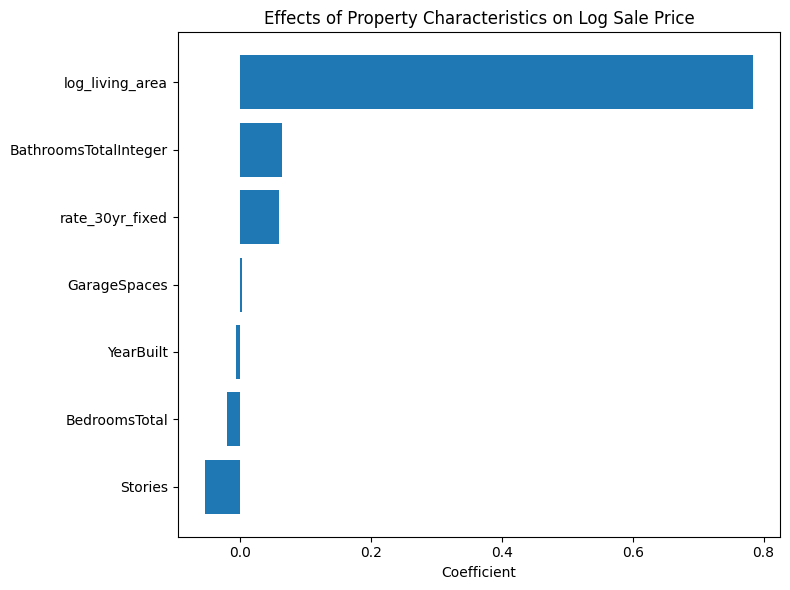

In [117]:
import matplotlib.pyplot as plt

plot_df = continuous[
    continuous["Variable"] != "Intercept"
].copy()

plot_df = plot_df.sort_values("Coefficient")

plt.figure(figsize=(8,6))
plt.barh(plot_df["Variable"], plot_df["Coefficient"])
plt.xlabel("Coefficient")
plt.title("Effects of Property Characteristics on Log Sale Price")
plt.tight_layout()
plt.show()

Living area is by far the most important structural characteristic Coefficient: 0.783 Highly significant (p < 0.001)Because both variables are in logarithms:A 1% increase in living area is associated with approximately a 0.78% increase in sale price, holding all other variables constant. Therefore, Living area is the strongest structural determinant of housing prices in the California residential market.Each additional bathroom is associated with about a 6–7% increase in sale price, after controlling for home size and other characteristics. A home with more bedrooms usually has smaller individual rooms.For homes of similar size, increasing the number of bedrooms is associated with a slight reduction in sale price.Additional garage spaces are associated with a modest increase in home value, although the economic effect is relatively small compared with living area and bathrooms. the negative coefficient suggests:Holding size constant, multi-story homes sell for slightly less than otherwise similar single-story homes.Possible explanations include:
* Buyer preference for single-story homes in some California markets.
* Older two-story developments.
* Accessibility concerns.

Overall. pricing model indicates that living area is the most important structural determinant of housing prices, with a 1% increase in living area associated with an estimated 0.78% increase in sale price (p < 0.001). Additional bathrooms were associated with approximately a 6–7% price premium, while garage spaces contributed a smaller positive effect. After controlling for living area, the number of bedrooms exhibited a slight negative association with price, suggesting that homes with more bedrooms but similar total floor area tend to have smaller room sizes. Multi-story homes also sold for slightly less than comparable single-story homes. Although mortgage rates showed a positive coefficient, this likely reflects broader market trends during the sample period rather than a causal relationship.